In [1]:
## Note for TA/Grader: 
## All comments start with ## are for further explanation/clarification

# Imports
library(tidyverse)
library(ggplot2)
library(scales)
library(themis)
# install.packages("tidymodels")
library(tidymodels)

# for upsample() to balance data
install.packages("groupdata2") 
library(groupdata2)

options(repr.plot.width=6, repr.plot.height=6)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor


Loading required package: recipes


Attaching package: ‘recipes’


The following object is masked from ‘package:stringr’:

    fixed


The following object is masked from ‘package:stats’:

    step


── Attaching packages ────────────────────────────────────── tidymodels 1.1.1 ──

✔ broom        1.0.6    

### An Exploration of Player Characteristics Which Result in High Playtime Contribution in a Minecraft Server using the KNN Classification Method 

### Introduction

Minecraft is a computer game in which the player can do various tasks such as explore a digital world made up of blocks, gather food and supplies, survive the night by avoiding dangerous predators such as spiders and zombies, and interact with other players in the community. The game is known as a “sandbox game” because there isn’t a clear goal to the game, there are many different things to do and different ways to play. Our project involves using two datasets of data collected from a Minecraft server moderated by a UBC Computer Science Research Group. We use these datasets to analyze which kinds of characteristics make an individual player prone to contributing higher playtime hours. The two datasets we use for this project are players.csv and sessions.csv. As described in the Dataset Description, the players.csv dataset captures information about Minecraft players on a server. Meanwhile, the sessions.csv dataset captures information about gameplay sessions of Minecraft players on a server. The following project report describes the steps we took to analyze and visualize the data, and the conclusions we drew from doing so.


#### Question:
Question 1: We would like to know which "kinds" of players are most likely to contribute a large amount of data so that we can target those players in our recruiting efforts.

#### Dataset Description:

1. **Players Data**
    - 196 rows (players), 9 variables
    - **Variables:**
      - `experience`: Character (player's experience level)
      - `subscribe`: Logical (whether the player subscribed to PlaiCraft's email updates)
      - `hashedEmail`: Character (unique hashed player email)
      - `played_hours`: Numeric (total hours played)
      - `name`: Character (player’s on-screen name)
      - `gender`: Character (player’s gender)
      - `age`: Numeric (player’s age)
      - `individualId`: Logical (if player has an associated ID)
      - `organizationName`: Logical (if player belongs to an organization)

2. **Sessions Data**
    - 1535 rows (sessions), 5 variables
    - **Variables:**
      - `hashedEmail`: Character (unique hashed player email)
      - `start_time`: Character (session start time)
      - `end_time`: Character (session end time)
      - `original_start_time`: Numeric (session start timestamp)
      - `original_end_time`: Numeric (session end timestamp)

**Potential Issues:**
- `individualId` and `organizationName` have only NA values, indicating irrelevance or incomplete data.
- The `gender` variable includes "Prefer not to say" and "Other" categories, which should be handled carefully as they impact analysis.
- An unbalanced gender distribution (e.g., more males) could introduce bias; further data is needed for assessment.
- `original_start_time` and `original_end_time` are numeric timestamps that need wrangling to calculate actual play time.

**Data Collection:**
The data was collected by a UBC Computer Science research group using a Minecraft server to track player actions. The aim is to analyze player behavior while managing server resources and targeting recruitment to handle the player load.

### Methods & Results


To identify players likely to contribute a large amount of data, we can use K-Nearest Neighbors (KNN) classification. The response variable is `played_hours`, while explanatory variables include `experience`, `age`, `gender`, `subscribe` after merging `org_players_data` and `org_sessions_data` by `hashedEmail`. We'll preprocess the data by handling missing values, balancing variables. Players will be classified into high and low data contributors based on a threshold for `played_hours`, which is its mean. KNN will predict data contribution by comparing players to others with similar characteristics, helping to identify key traits that correlate with high playtime for targeted recruitment.



We will begin by reading in the data using the read_csv function. 

#### 1. Load data

In [2]:
# 1. Load data
players_url <- "https://drive.google.com/uc?export=download&id=1Mw9vW0hjTJwRWx0bDXiSpYsO3gKogaPz"
sessions_url <- "https://drive.google.com/uc?export=download&id=14O91N5OlVkvdGxXNJUj5jIsV5RexhzbB"
org_players_data <- read_csv(players_url)
org_sessions_data <- read_csv(sessions_url)

print("Original players data : ")
head(org_players_data)

print("Original sessions data :")
head(org_sessions_data)

Rows: 196 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, age
lgl (3): subscribe, individualId, organizationName

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1535 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): hashedEmail, start_time, end_time
dbl (2): original_start_time, original_end_time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "Original players data : "


experience,subscribe,hashedEmail,played_hours,name,gender,age,individualId,organizationName
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<lgl>,<lgl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9,NA,NA
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17,NA,NA
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17,NA,NA
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21,NA,NA
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21,NA,NA
Amateur,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17,NA,NA


[1] "Original sessions data :"


hashedEmail,start_time,end_time,original_start_time,original_end_time
<chr>,<chr>,<chr>,<dbl>,<dbl>
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,30/06/2024 18:12,30/06/2024 18:24,1.71977e+12,1.71977e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,17/06/2024 23:33,17/06/2024 23:46,1.71867e+12,1.71867e+12
f8f5477f5a2e53616ae37421b1c660b971192bd8ff77e3398304c7ae42581fdc,25/07/2024 17:34,25/07/2024 17:57,1.72193e+12,1.72193e+12
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,25/07/2024 03:22,25/07/2024 03:58,1.72188e+12,1.72188e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,25/05/2024 16:01,25/05/2024 16:12,1.71665e+12,1.71665e+12
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,23/06/2024 15:08,23/06/2024 17:10,1.71916e+12,1.71916e+12


#### 2. Wrangles and cleans the data to the format necessary for the planned analysis

We will filter out `individualId`, `organizationName` to remove columns where both values are NA. 

We then will summarize each player's total hours (`played_hours_sum`) as well as the number of `sessions_played`. We will also do calculations to create a new column called `played_hours_sum`, as well as using the `mutate` and `group_by` and `summarize` functions, grouping by `hashed_email.`

In the third code cell we will pull the total played hours for a specific player from the `org_players_data`and the `org_sessions_data` to determine if there are discrepancies between the total hours played by a player in the two datasets. The output below shows that the summed played hours differs in the two datasets, therefore we will use the played hours from the `org_players_data` dataset as the response varaible as the calculations from sessions data may be erroneous. 

In [3]:
# Filter individualId, organizationName that are not NA:
org_players_data |> 
  filter(!is.na(individualId) | !is.na(organizationName)) 

## turns out all NA for both individualId and organizationName, 
## thus these two variables will be excluded for analysis 
## as they do not contribute valuable data

experience,subscribe,hashedEmail,played_hours,name,gender,age,individualId,organizationName
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<lgl>,<lgl>


In [4]:
## Summarize total hours and total sessions played for each player (hashedEmail):
session_summary <- org_sessions_data |>
  mutate(
    original_start_time = as.POSIXct(original_start_time / 1000, origin = "1970-01-01", tz = "UTC"),
    original_end_time = as.POSIXct(original_end_time / 1000, origin = "1970-01-01", tz = "UTC")
  ) |>
  mutate(duration_seconds = as.numeric(difftime(original_end_time, original_start_time, units = "secs"))) |>
  mutate(duration_hours = duration_seconds / 3600) |>  # Convert seconds to hours
  group_by(hashedEmail)  |>
  summarize(played_hours_sum = sum(duration_hours), sessions_played = n())

head(session_summary)

hashedEmail,played_hours_sum,sessions_played
<chr>,<dbl>,<int>
0088b5e134c3f0498a18c7ea6b8d77b4b0ff1636fc93355ccc95b45423367832,2.777778,2
060aca80f8cfbf1c91553a72f4d5ec8034764b05ab59fe8e1cf0eee9a7b67967,0.000000,1
0ce7bfa910d47fc91f21a7b3acd8f33bde6db57912ce0290fa0437ce0b97f387,0.000000,1
0d4d71be33e2bc7266ee4983002bd930f69d304288a8663529c875f40f1750f3,11.111111,13
0d70dd9cac34d646c810b1846fe6a85b9e288a76f5dcab9c1ff1a0e7ca200b3a,2.777778,2
11006065e9412650e99eea4a4aaaf0399bc338006f85e80cc82d18b49f0e2aa4,0.000000,1


In [5]:
## As the output below shows that the summed played hours from sessions dataset 
## is different from the corresponding value in the players dataset, 
## we will use instead the played_hours from players dataset as the response variable 
## given the inconsistency, as the calculation from sessions data might be erroneous

total_played_hrs_onePlayer <- session_summary |>
    filter(hashedEmail == "f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d") |>
    select(played_hours_sum) |>
    pull()


# Print the result of summed hours of the player to verify
print("played hours of the player summed from sessions dataset: ")
print(total_played_hrs_onePlayer)  # which is greater than the played_hours 30.3 in players_data 


played_hours_same_player <- org_players_data |>
    filter(hashedEmail == "f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d") |>
    select(played_hours) |>
    pull()

print("played hours of the same player in players dataset: ")
print(played_hours_same_player)


[1] "played hours of the player summed from sessions dataset: "
[1] 33.33333
[1] "played hours of the same player in players dataset: "
[1] 30.3


#### 3. Performs a summary of the data set that is relevant for exploratory data analysis related to the planned analysis 

Below we will combine both `org_players_data` with `session_summary` by the `hashedEmail` of players to create an aggregate dataset. We will then remove variables that are irrelevant to our analysis. Additionally, we will `mutate` `experience`,`subscribe`, and `gender` so that they are `as_factor` and can be used in knn classification. 

In [6]:
## Exclude the players that do not exist in the sessions dataset when combining, 
## Since it does not help the analysis if the players haven't played yet.
## Also exclude variables/features that are not contributive as mentioned above (or inconsistent in the case of played_hours_sum)
## (name and hashedEmail are also excluded as they are just for individual player identification). 
## Categorical variables are refactored

combined_play_data <- org_players_data |>
    right_join(session_summary, by = "hashedEmail") |>
    select(-played_hours_sum, -individualId, -organizationName, -name, -hashedEmail) |>
    mutate(experience = as_factor(experience), subscribe = as_factor(subscribe), gender = as_factor(gender)) |>
    arrange(played_hours)

head(combined_play_data)
tail(combined_play_data)
dim(combined_play_data)

experience,subscribe,played_hours,gender,age,sessions_played
<fct>,<fct>,<dbl>,<fct>,<dbl>,<int>
Veteran,FALSE,0,Male,17,1
Amateur,FALSE,0,Male,21,1
Regular,TRUE,0,Male,17,1
Amateur,TRUE,0,Female,26,1
Amateur,TRUE,0,Female,17,1
Amateur,FALSE,0,Two-Spirited,26,1


experience,subscribe,played_hours,gender,age,sessions_played
<fct>,<fct>,<dbl>,<fct>,<dbl>,<int>
Amateur,TRUE,53.9,Male,17,130
Amateur,TRUE,56.1,Male,23,310
Amateur,TRUE,150.0,Female,16,159
Regular,TRUE,178.2,Female,19,147
Regular,TRUE,218.1,Non-binary,20,95
Regular,TRUE,223.1,Male,17,219


[1] 125   6

#### 4. creates a visualization of the dataset that is relevant for exploratory data analysis related to the planned analysis

We will begin by creating a histogram for `played_hours` to explore its distribution as seen in Figure 4.1. We will then do the same for `sessions_played` (Figure 4.2).

The next step will be to calculate and print summary statistics (mean and median) for `played_hours` and `sessions_played`, using the mean as a benchmark for setting a threshold of highly contributive players (as the majority of players contributed 0 hours/sessions, therefore the median is not an effective benchmark in this case). 

In Figure 4.3 we generated a scatter plot using `ggplot2` to visualize the relationship between `sessions_played` and `played_hours`. Since there is a large gap between players in terms of hours/sessions played, and the majority of players contributed 0 hours (as seen in Figure 4.1 and  4.2), logmarithimc scales are used to better display the wide-ranging data. There appears to be a strong, positive relationship, which is reasonable as more sessions could indicate more hours played. 

We then created Figures 4.4-4.8 to explore the relationships between `played_hours` and the different variables, as well as the gender distribution (Figure 4.7). 




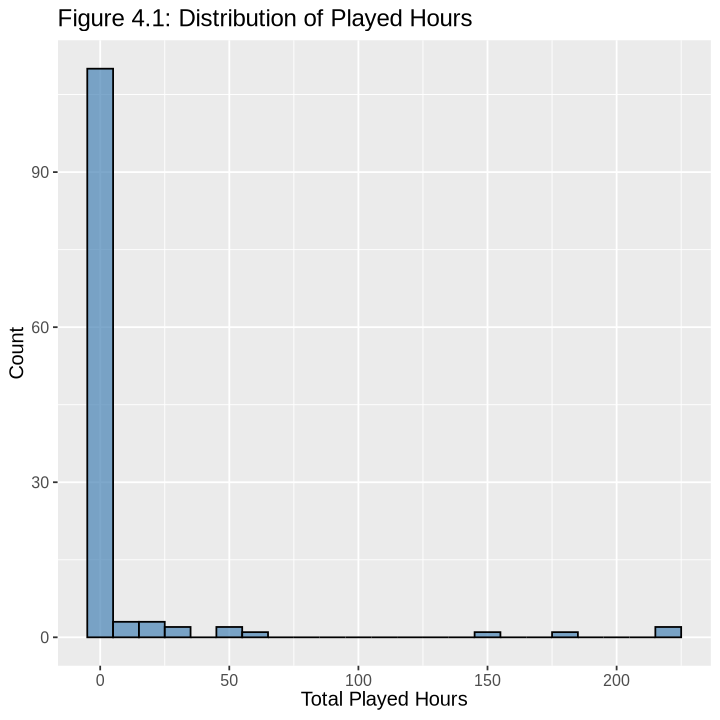

In [7]:
# Histogram for played_hours

ggplot(combined_play_data, aes(x = played_hours)) +
  geom_histogram(binwidth = 10, fill = "steelblue", color = "black", alpha = 0.7) +
  labs(title = "Figure 4.1: Distribution of Played Hours", 
       x = "Total Played Hours",
       y = "Count") +
  theme(text = element_text(size = 12))

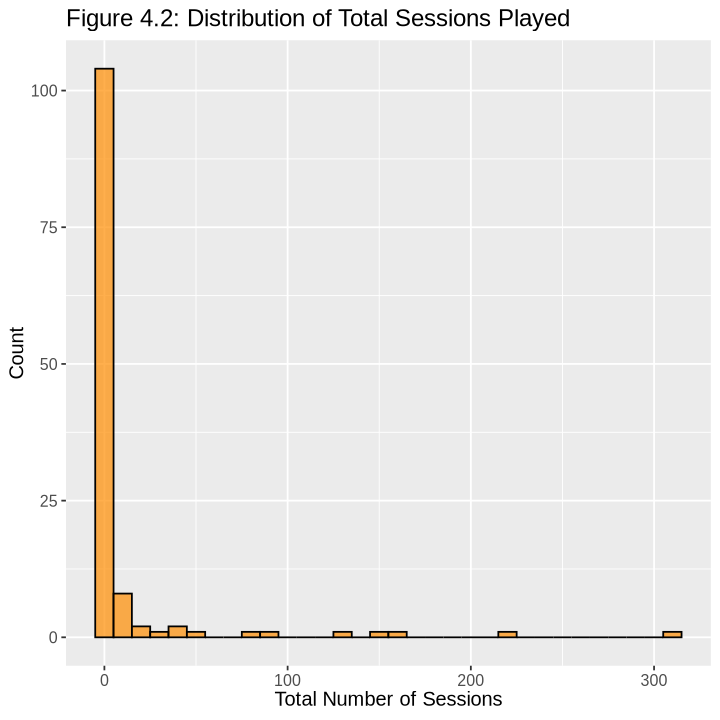

In [8]:
# Histogram for sessions_played
ggplot(combined_play_data, aes(x = sessions_played)) +
  geom_histogram(binwidth = 10, fill = "darkorange", color = "black", alpha = 0.7) +
  labs(title = "Figure 4.2: Distribution of Total Sessions Played", 
       x = "Total Number of Sessions",
       y = "Count") +
  theme(text = element_text(size = 12))

In [9]:
# Get the average/median played hours and average/median number of played sessions

## The MEAN will be used as the benchmark for setting threshold of highly contributive players
## (as the majority of player contributed 0 hours/sessions,
## median is not a good benchmark in this case)

cat(sprintf("Average played hours : %.2f \n", combined_play_data |> summarize(mean(played_hours)) |> pull()))
cat(sprintf("Average played sessions : %.2f \n", combined_play_data |> summarize(mean(sessions_played)) |> pull()))
cat(sprintf("Median played hours : %.2f \n", combined_play_data |> summarize(median(played_hours)) |> pull()))
cat(sprintf("Median played sessions : %.2f  \n", combined_play_data |> summarize(median(sessions_played)) |> pull()))

Average played hours : 9.17 
Average played sessions : 12.28 
Median played hours : 0.30 
Median played sessions : 1.00  


Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”


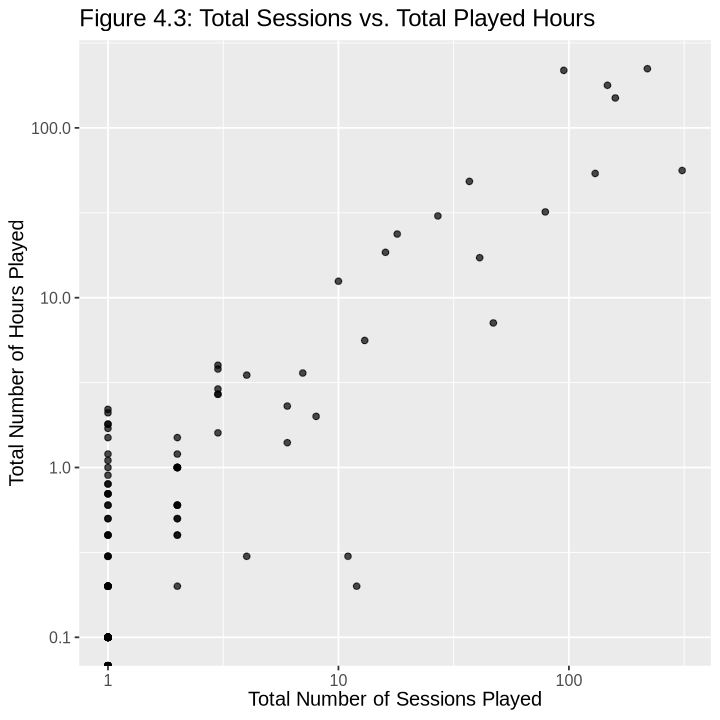

In [10]:
# Scatter plot for sessions_played vs. played_hours 

## Since there's big difference/gap between players in terms of hours/sessions played, 
## and the majority of players played 0 hours as seen from the above histograms, 
## scales are used here to make the relationship between played_hours and sessions_played in the scatter plot more apparent,
## And it appears there is a strong positive relationship, which is reasonable as more sessions could mean more hours played/spent

ggplot(combined_play_data, aes(x = sessions_played, y= played_hours)) +
  geom_point(alpha = 0.7) +
  labs(title = "Figure 4.3: Total Sessions vs. Total Played Hours", 
       x = "Total Number of Sessions Played",
       y = "Total Number of Hours Played") +
  scale_x_log10() +
  scale_y_log10()+
  theme(text = element_text(size = 12))

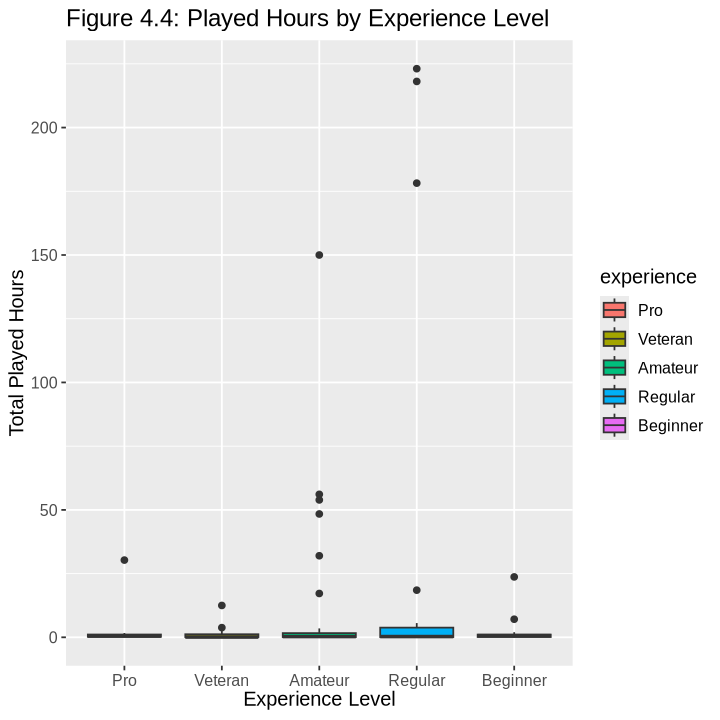

In [11]:
# Boxplot for played_hours by experience level
ggplot(combined_play_data, aes(x = experience, y = played_hours, fill = experience)) +
  geom_boxplot() +
  labs(title = "Figure 4.4: Played Hours by Experience Level", 
       x = "Experience Level", 
       y = "Total Played Hours") +
  theme(text = element_text(size = 12)) 

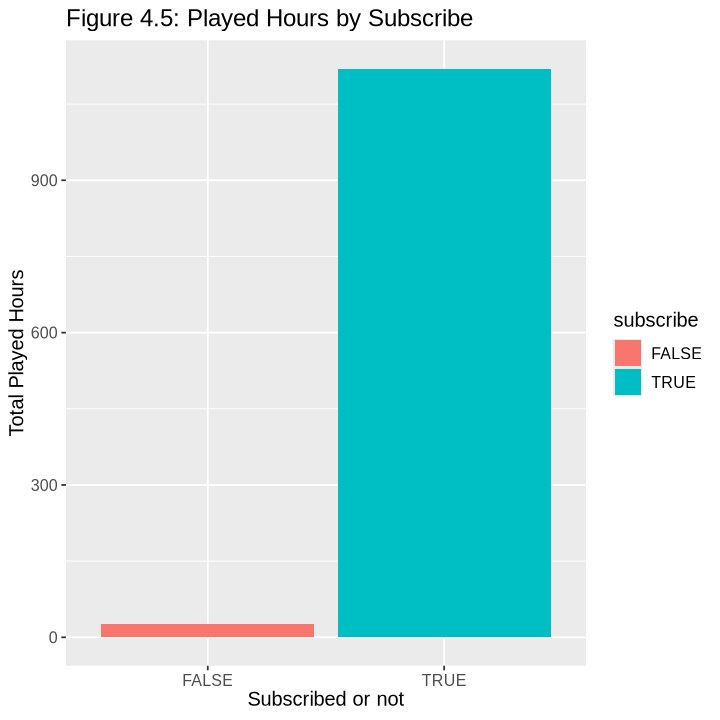

In [12]:
# Bar chart for played_hours vs subscribe 

ggplot(combined_play_data, aes(x = subscribe, y = played_hours, fill = subscribe)) +
  geom_bar(stat = "identity") +
  labs(title = "Figure 4.5: Played Hours by Subscribe", 
       x = "Subscribed or not", 
       y = "Total Played Hours") +
  theme(text = element_text(size = 12)) 

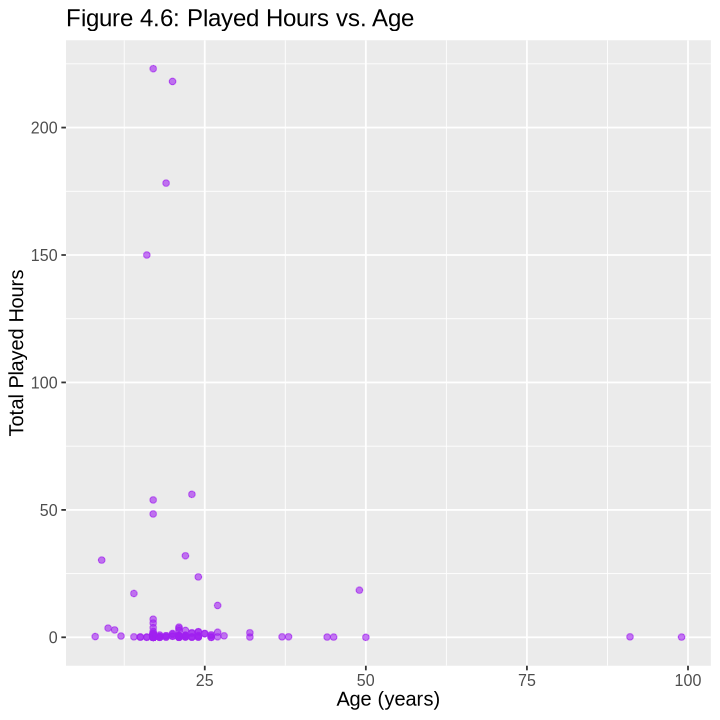

In [13]:
# Scatter plot for played_hours vs. age
ggplot(combined_play_data, aes(x = age, y = played_hours)) +
  geom_point(color = "purple", alpha = 0.6) +
  labs(title = "Figure 4.6: Played Hours vs. Age", 
       x = "Age (years)", 
       y = "Total Played Hours") +
  theme(text = element_text(size = 12)) 

## The Figure 4.6 below shows outlier players of age > 75, 
## who also contributed no play hours, 
## so they will be cleaned/excluded from the combined analysis
combined_play_data <- combined_play_data |>
    filter(age < 75)

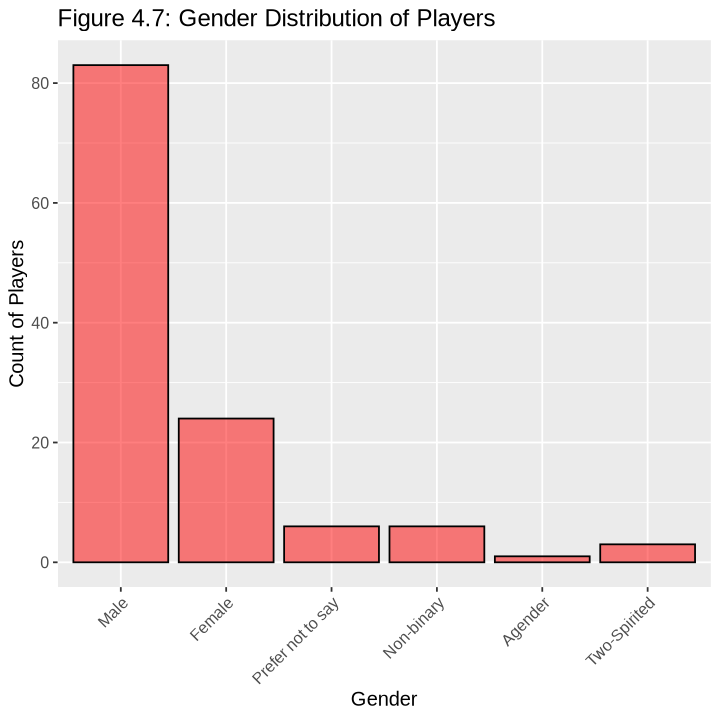

In [14]:
# Bar chart for the gender distribution

ggplot(combined_play_data, aes(x = gender)) +
  geom_bar(fill = "red", color = "black", alpha = 0.5) +
  labs(title = "Figure 4.7: Gender Distribution of Players", 
       x = "Gender", 
       y = "Count of Players") +
  theme(text = element_text(size = 12), axis.text.x = element_text(angle = 45, hjust = 1))



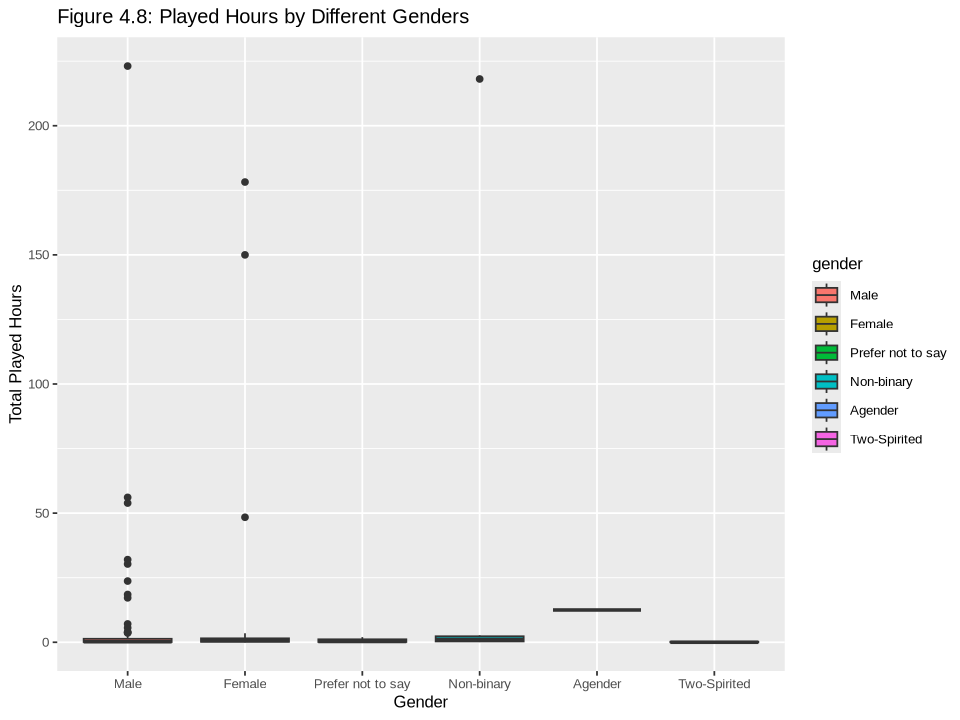

In [15]:
# Box Plot for total played_hours by gender group
options(repr.plot.width=8, repr.plot.height=6)
ggplot(combined_play_data, aes(x = gender, y = played_hours, fill = gender)) +
  geom_boxplot() +
  labs(title = "Figure 4.8: Played Hours by Different Genders", 
       x = "Gender", 
       y = "Total Played Hours") +
  theme(text = element_text(size = 10)) 

#### 5. performs the data analysis

The *Figure 4.3: Total Sessions vs. Total Played Hours* shows that there is a strong positive relationship, which is reasonable as more sessions could mean more hours played/spent. Hence, we could use just played_hours from the original players dataset as the target (as using both could be redundant).
The visualizations above show that the `played_hours` appears to be affected by every variable:
- **Experience**: Players categorized as 'Amateur' or 'Regular' tend to log higher `played_hours`, suggesting that experience level is associated with greater gameplay time, and there is variability within each experience category.
- **Subscribe**: Subscribed players (`subscribe = TRUE`) shows higher `played_hours`, suggesting that subscription to PlaiCraft's email updates encourages longer engagement compared to non-subscribed players. 
- **Gender**: There are differences in the distribution of `played_hours` across gender categories, and  the box plot shows males have a wider range of playtime.
- **Age**: The scatterplot of `age` versus `played_hours` shows that younger players around 20 tend to have longer playtime. However, age alone does not have a strong linear relationship with gameplay duration.


Also there is a clear imbalance in the dataset, with potential bias from a significant greater proportion of males. We'll thus balance the dataset for equal gender contribution. We'll do so by creating a binary target column called `high_contribution`to use for KNN classification based on the threshold using the mean of `played_hours`. 

As there is a class imbalance in the `high_contribution` column, we will then perform unsampling on the `classified_player_data` dataset to balance our target variable (`high_contribution`), otherwise there may be a bias when predicting.  

In [16]:
summary(combined_play_data['gender'])

               gender  
 Male             :83  
 Female           :24  
 Prefer not to say: 6  
 Non-binary       : 6  
 Agender          : 1  
 Two-Spirited     : 3  
 Other            : 0  

In [17]:
# Balance the gender data distribution for later analysis
set.seed(123)
balanced_player_data <- upsample(combined_play_data, cat_col = 'gender')
summary(balanced_player_data['gender'])


               gender  
 Male             :83  
 Female           :83  
 Prefer not to say:83  
 Non-binary       :83  
 Agender          :83  
 Two-Spirited     :83  
 Other            : 0  

In [18]:
## create a binary target column high_contribution for KNN classification
## based on the threshold(mean of played_hours)
set.seed(123)
mean_played_hours <-  mean(balanced_player_data$played_hours)
mean_played_hours

classified_player_data <- balanced_player_data |>
    mutate(high_contribution = as_factor(played_hours >= mean_played_hours)) |>
    arrange(played_hours) |>
    select(-played_hours, -sessions_played) 

summary(classified_player_data['high_contribution'])

## Since there is imbalance for the target high_contribution, which could cause bias in prediction,
## so we will balance the dataset based on the target variable:
classified_player_data <- upsample(classified_player_data, cat_col = 'high_contribution')
summary(classified_player_data['high_contribution'])

head(classified_player_data)
tail(classified_player_data)

[1] 9.355422

 high_contribution
 FALSE:389        
 TRUE :109        

 high_contribution
 FALSE:389        
 TRUE :389        

,experience,subscribe,gender,age,high_contribution
,<fct>,<fct>,<fct>,<dbl>,<fct>
1,Veteran,FALSE,Male,17,FALSE
2,Amateur,FALSE,Male,21,FALSE
3,Regular,TRUE,Male,17,FALSE
4,Beginner,TRUE,Male,17,FALSE
5,Regular,FALSE,Male,18,FALSE
6,Amateur,TRUE,Male,16,FALSE


,experience,subscribe,gender,age,high_contribution
,<fct>,<fct>,<fct>,<dbl>,<fct>
773,Veteran,TRUE,Agender,27,TRUE
774,Veteran,TRUE,Agender,27,TRUE
775,Amateur,TRUE,Female,17,TRUE
776,Veteran,TRUE,Agender,27,TRUE
777,Veteran,TRUE,Agender,27,TRUE
778,Veteran,TRUE,Agender,27,TRUE


#### 6. KNN analysis and visualization 
To address the question of identifying which "kinds" of players are most likely to contribute a large amount of data, we propose using the **K-Nearest Neighbors (KNN) classification** method. KNN is appropriate because it classifies players into **high** or **low** data contributors based on the similarity of their features, such as age, experience, gender, and sessions played. The target variable, **played_hours**, will be transformed into a binary column by setting a threshold (mean of the `played_hu) to distinguish between high and low data contributors.

The method assumes that players with similar characteristics will contribute similarly to playtime. Since KNN is based on distance metrics, it requires data to be scaled to ensure no single feature dominates the calculation. A key consideration is tuning the **k-value** (number of neighbors), which controls the balance between underfitting and overfitting. To select the optimal k, we will use **cross-validation** and evaluate performance metrics, such as accuracy or precision/recall, for various k-values.

The dataset will be split into **80% training** and **20% testing** sets. We will preprocess the data by handling missing values, encoding categorical variables, and scaling features. Cross-validation will be used to select the best model and fine-tune hyperparameters, including the k-value, to improve prediction accuracy.

After the best k is found, we will use the test dataset to get the recall, precision metrics, and confusion matrix to verfiy prediction results. 

We then create Figures 6.2 and 6.3 to look into the contribution distribution by age, gender, and experience. 

In [19]:
# split the data for cross validation:
set.seed(123)
players_split <- initial_split(classified_player_data, prop = 0.8, strata = high_contribution)
players_train <- training(players_split)
players_test <- testing(players_split)
glimpse(players_train)
dim(players_test)

Rows: 622
Columns: 5
$ experience        <fct> Amateur, Beginner, Regular, Amateur, Regular, Amateu…
$ subscribe         <fct> FALSE, TRUE, FALSE, TRUE, FALSE, TRUE, TRUE, FALSE, …
$ gender            <fct> Male, Male, Male, Male, Male, Female, Female, Female…
$ age               <dbl> 21, 17, 18, 17, 50, 26, 17, 17, 17, 17, 17, 17, 17, …
$ high_contribution <fct> FALSE, FALSE, FALSE, FALSE, FALSE, FALSE, FALSE, FAL…


[1] 156   5

In [28]:
# Tune the knn classifier
set.seed(123)
# -- DEBUGGING : cannot upsample FALSE/TRUE target variable, which will cause error in fitting--
players_recipe <- recipe(high_contribution ~ ., data = players_train) 

players_recipe

players_vfold <- vfold_cv(players_train, v = 5, strata = high_contribution)
# players_vfold  # -- DEBUGGING --

k_vals <- tibble(neighbors = seq(from = 1, to = 20, by = 1))

knn_spec <- nearest_neighbor(weight_func = "rectangular",
                             neighbors = tune()) |>
  set_engine("kknn") |>
  set_mode("classification")

knn_results <- workflow() |>
  add_recipe(players_recipe) |>
  add_model(knn_spec) |>
  tune_grid(resamples = players_vfold, grid = k_vals) |>
  collect_metrics()

accuracies <- knn_results |>
  filter(.metric == "accuracy") |>
  arrange(desc(mean))

accuracies



── Recipe ──────────────────────────────────────────────────────────────────────



── Inputs 

Number of variables by role

outcome:   1
predictor: 4



neighbors,.metric,.estimator,mean,n,std_err,.config
<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
6,accuracy,binary,0.9549411,5,0.006602667,Preprocessor1_Model06
5,accuracy,binary,0.9485407,5,0.008319252,Preprocessor1_Model05
11,accuracy,binary,0.9469534,5,0.006013606,Preprocessor1_Model11
12,accuracy,binary,0.9453405,5,0.006929253,Preprocessor1_Model12
9,accuracy,binary,0.9421403,5,0.006892620,Preprocessor1_Model09
10,accuracy,binary,0.9421403,5,0.006892620,Preprocessor1_Model10
4,accuracy,binary,0.9389401,5,0.012599284,Preprocessor1_Model04
2,accuracy,binary,0.9389401,5,0.007394842,Preprocessor1_Model02
1,accuracy,binary,0.9373272,5,0.007750640,Preprocessor1_Model01


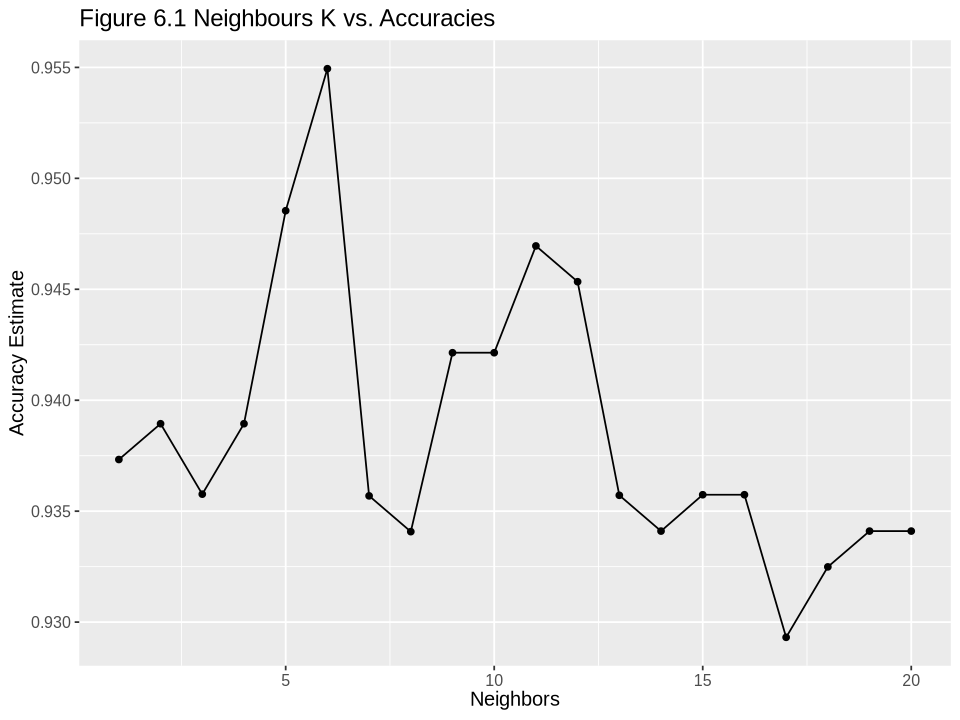

In [21]:
# Visualization for Neighbours K vs. Accuracies
accuracy_vs_k <- ggplot(accuracies, aes(x = neighbors, y = mean)) +
  geom_point() +
  geom_line() +
  labs(x = "Neighbors", y = "Accuracy Estimate", title="Figure 6.1 Neighbours K vs. Accuracies") +
  theme(text = element_text(size = 12))

accuracy_vs_k

In [22]:
# Get the best k from tuning results
best_k <- accuracies |>
        head(1) |>
        pull(neighbors)
best_k

[1] 6

In [23]:
## Evaluate on the test set
set.seed(123)
# Create a model with best_k
knn_spec_bestK <- nearest_neighbor(weight_func = "rectangular", neighbors = best_k) |>
  set_engine("kknn") |>
  set_mode("classification")

knn_fit_bestK <- workflow() |>
  add_recipe(players_recipe) |>
  add_model(knn_spec_bestK) |>
  fit(data = players_train)

knn_fit_bestK

# predict on test data set
players_test_predictions <- predict(knn_fit_bestK, players_test) |>
  bind_cols(players_test)

# get accuracies of training
players_test_predictions |>
  metrics(truth = high_contribution, estimate = .pred_class) |>
  filter(.metric == "accuracy")

══ Workflow [trained] ══════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: nearest_neighbor()

── Preprocessor ────────────────────────────────────────────────────────────────
0 Recipe Steps

── Model ───────────────────────────────────────────────────────────────────────

Call:
kknn::train.kknn(formula = ..y ~ ., data = data, ks = min_rows(6,     data, 5), kernel = ~"rectangular")

Type of response variable: nominal
Minimal misclassification: 0.04823151
Best kernel: rectangular
Best k: 6

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.9871795


In [24]:
# get the recall, precision metrics, and confusion matrix to verify the prediction results:
players_test_predictions |>
    recall(truth = high_contribution, estimate = .pred_class, event_level="second")

players_test_predictions |>
    precision(truth = high_contribution, estimate = .pred_class, event_level="second")

confusion <- players_test_predictions |>
             conf_mat(truth = high_contribution, estimate = .pred_class)
confusion

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
recall,binary,0.974359


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
precision,binary,1


          Truth
Prediction FALSE TRUE
     FALSE    78    2
     TRUE      0   76

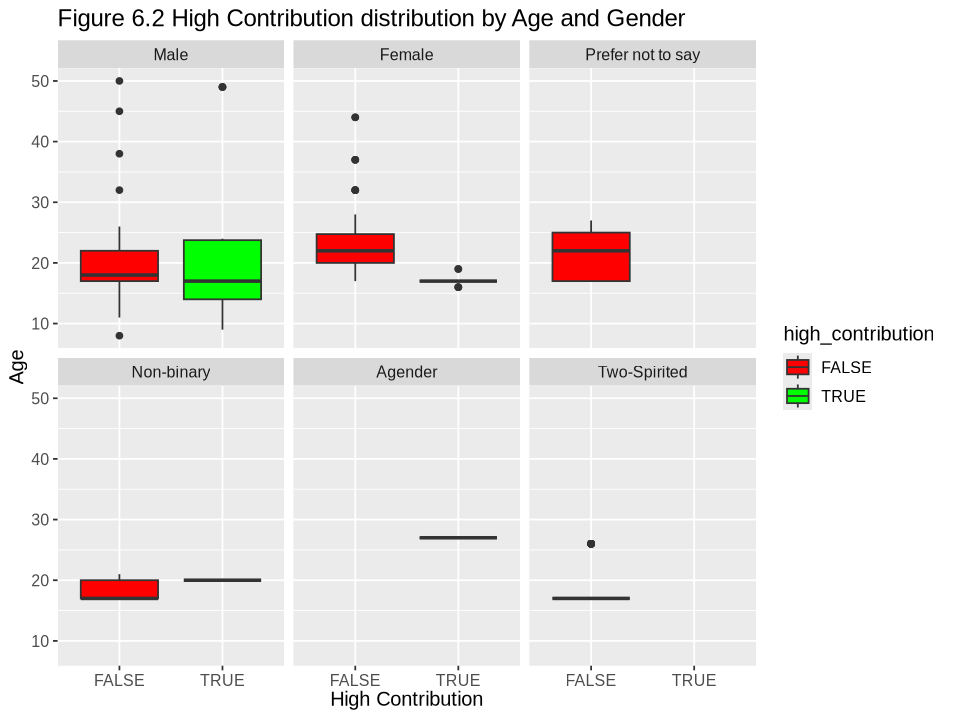

In [25]:
# Boxplot for age by high_contribution, faceted by gender
ggplot(players_train, aes(x = high_contribution, y = age, fill = high_contribution)) +
  geom_boxplot() +
  facet_wrap(~ gender) +
  labs(title = "Figure 6.2 High Contribution distribution by Age and Gender",
       x = "High Contribution", 
       y = "Age") +
  scale_fill_manual(values = c("red", "green")) +
  theme(text = element_text(size = 12))

## From the plot, it appears young (age < 25) male players have high contributions.

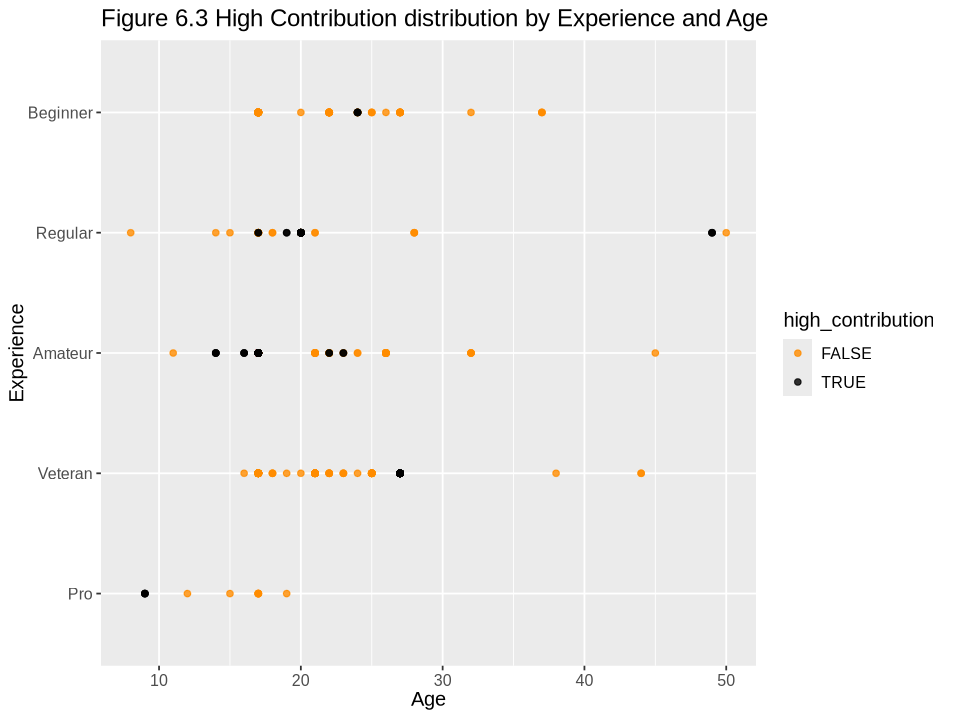

In [26]:
# Scatter plot for High Contribution distribution by Experience and Age
ggplot(players_train, aes(x = age, y = experience, color = high_contribution)) +
  geom_point(alpha = 0.8) +
  labs(title = "Figure 6.3 High Contribution distribution by Experience and Age",
       x = "Age", 
       y = "Experience") +
  scale_color_manual(values = c("darkorange", "black")) +
  theme(text = element_text(size = 12))
## From the plot, it appears young (age < 30) regular and amateur players tend to have high contributions

### Discussion

#### **Summary of Individual Demographics**

**Age (Figure 4.6)**

When looking at the age distribution of the players within the data set, we found that the majority of the players were less than 25 years old. We observed that individuals between the age range of 12 and 25 contributed the most hours of playtime. Though most players contributed close to 0 hours, a few players within this age range contributed significantly more (with the highest contribution being almost 225 hours)


**Gender (Figure 4.7 and 4.8)**

The gender distribution of the players consists primarily of males (81-82) with the second largest being females (21-22). When considering the total hours played by different genders, the males contributed the most with the majority of contributions within the time range of 5 to 55 hours. Among the males and females there were a few individuals who contributed hundreds of hours of playtime (there were more females which contributed a significantly large amount of hours than any other gender category).

**Experience (Figure 4.4)**

Looking at experience, there was a split between most played hours and which group had the most individuals play. 

The most played hours came from the group of players which considered themselves regular players as there were two individuals with close to 225 hours of play time each and one individual with around 175 hours of playtime.

The group that had the most consistent players were from the amateur experience level, with the majority contributing over 25 hours (most contributing around 50 hours).

**Subscribed (Figure 4.5)**

Almost all of the total hours contributed by all players were from players subscribed to the email notifications.

#### **Summary of Combined Demographics**

**Age and Gender (Figure 6.2)**

In the combined demographic consisting of both age and gender, the group that we found was most likely to contribute were males within the age range of 14 to 24 years old ( the median age range being around 16 to 17 years, with an upper quartile of 24 years and a lower quartile of 14 years old).

The other categories from figure 6.2 only give median ages which are as follows.

For females, the median age which was found most likely to contribute was 17.
For non-binary and agender individuals the median age ranges were 20 and 26 respectively.

**Experience and Age (Figure 6.3)**

In this combined demographic, we found that the experience level with the highest amount of ages that are most likely to contribute data are the amateurs, which are followed by players with a regular experience level. A common trend amongst all of the groups is that almost all of the ages which were found most likely to contribute data were under the age of 30.



#### **Was this expected?**


The majority of these results were expected with the exception as to which experience levels are most likely to contribute data. Generally we would expect younger individuals (30 years old or younger) more likely to contribute data which was consistent with the data that we observed over all individual and combined demographics. Furthermore, we also generally expected males to be more likely to contribute data over all other gender categories due to the higher proportion of male players playing video games which was also consistent with the data observed (the majority of players were male and males contributed the most total hours, followed closely by females). What was unexpected were the contributions made by players that identified themselves as being veterans or pros. We expected that players with the higher levels of experience would have contributed more total play time hours (and be more likely to contribute data) but this was not the case. We consistently found that the players with these experience levels contributed the least amount of play time hours overall and were also among the least likely to contribute data towards the study.


#### **Impact**

By marketing the study towards the demographics that we found were more likely to contribute data, the researchers are more likely to accumulate a larger number of players which will consistently play the game and thus contribute more data overall.


#### **What Future Questions can this lead to?**

How will this data change as the proportion of female gamers comes closer to the proportion of male gamers?

Why are players with higher levels of experience playing less than players with lower levels of experience?


### Reference

1. [Upsample() in R](https://search.r-project.org/CRAN/refmans/groupdata2/html/upsample.html)
2. [Classfication II](https://datasciencebook.ca/classification2.html)